# Compose datasets with SynSet

`SynSet` combines several generators into one long-format panel — the way to build a dataset that *mixes* behaviors (say, trending random walks alongside daily-seasonal demand) instead of repeating one shape. Each generator contributes a batch of series, and their ids are numbered sequentially so the result stays a single, model-ready frame.

::: {.callout-tip}
## SynSet vs. balanced_pool vs. generate_series

`SynSet` is the low-level composer you control directly. [`balanced_pool`](/synforecast/docs/capabilities/balanced_pool.html) is a ready-made list of 42 generators you can drop into a `SynSet`, and [`generate_series`](/synforecast/docs/getting-started/quickstart.html) wraps that pool in a one-liner. Use `SynSet` when you want an explicit, curated mix of generators.
:::

In [ ]:
import matplotlib.pyplot as plt
import polars as pl

from synforecast import SynSet
from synforecast.generators import RandomWalkGenerator, SeasonalGenerator

## Define generators

Create a random walk generator and a seasonal generator with different parameter configurations.

In [ ]:
rw_params = {
    "min_length": 100,
    "max_length": 150,
    "freq": "h",
    "drift": 0.1,
    "volatility": 1.5,
    "start_value": 100.0,
    "seed": 42,
}

seasonal_params = {
    "min_length": 100,
    "max_length": 150,
    "freq": "h",
    "seasonality_period": 24,
    "seasonality_amplitude": 15.0,
    "trend": 0.05,
    "noise_level": 2.0,
    "base_level": 50.0,
    "seed": 123,
}

rw_gen = RandomWalkGenerator(engine="polars", **rw_params)
seasonal_gen = SeasonalGenerator(engine="polars", **seasonal_params)

## Generate the dataset

`generate(n_series_per_generator=3)` draws 3 series from each generator — 6 in total. Ids are assigned in generator order: `0-2` are the random walks, `3-5` the seasonal series. Pass `start_id` to offset the numbering when stitching several datasets together.

In [ ]:
dataset = SynSet([rw_gen, seasonal_gen])
df = dataset.generate(n_series_per_generator=3)

print(f"Generated {df['unique_id'].n_unique()} time series")
print(f"Total observations: {len(df)}")
df.head(10)

Generated 6 time series
Total observations: 740


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,100.620958
"""0""",2000-01-01 01:00:00,102.500707
"""0""",2000-01-01 02:00:00,101.104897
"""0""",2000-01-01 03:00:00,100.564106
"""0""",2000-01-01 04:00:00,99.076724
"""0""",2000-01-01 05:00:00,97.674284
"""0""",2000-01-01 06:00:00,96.714608
"""0""",2000-01-01 07:00:00,97.294935
"""0""",2000-01-01 08:00:00,98.929896


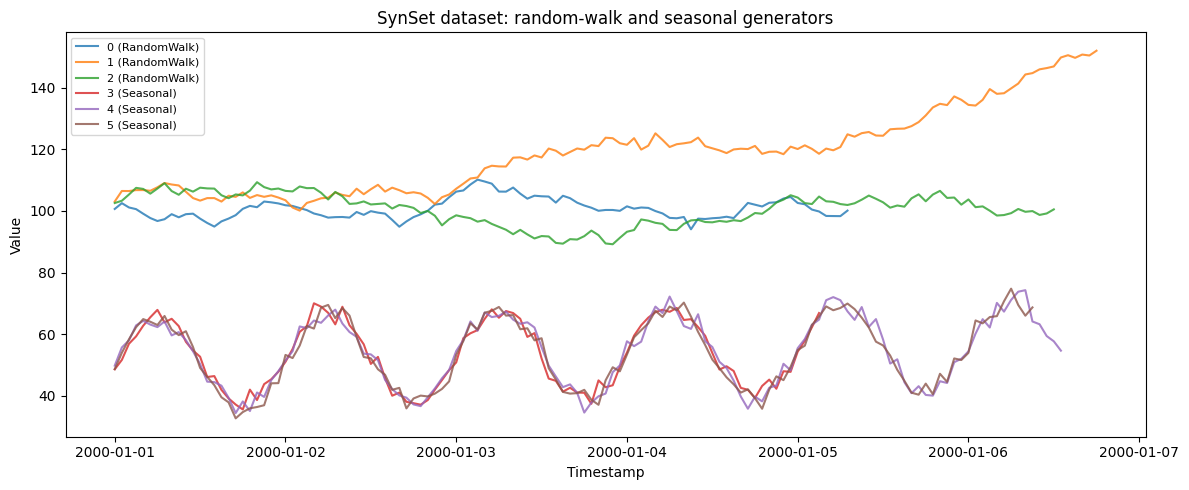

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
unique_ids = df["unique_id"].unique().to_list()

for uid in unique_ids:
    series = df.filter(pl.col("unique_id") == uid)
    # IDs 0, 1, 2 are RandomWalk; IDs 3, 4, 5 are Seasonal.
    gen_type = "RandomWalk" if int(uid) < 3 else "Seasonal"
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=f"{uid} ({gen_type})", alpha=0.8)
ax.set_title("SynSet dataset: random-walk and seasonal generators")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Statistics by series

Compare summary statistics across all generated series.

In [ ]:
stats = (
    df.group_by("unique_id")
    .agg(
        [
            pl.col("y").count().alias("count"),
            pl.col("y").min().alias("min_value"),
            pl.col("y").max().alias("max_value"),
            pl.col("y").mean().alias("mean_value"),
            pl.col("y").std().alias("std_value"),
        ]
    )
    .sort("unique_id")
)
stats

unique_id,count,min_value,max_value,mean_value,std_value
cat,u32,f64,f64,f64,f64
"""0""",104,94.028521,110.129544,100.735208,3.266454
"""1""",139,100.090121,151.940789,118.881905,13.27846
"""2""",133,89.176748,109.298167,100.537712,5.13869
"""3""",100,35.600282,70.029241,53.290106,10.264408
"""4""",134,34.431384,74.281368,54.466225,10.722442
"""5""",130,32.718865,74.773261,54.063785,11.005692


## Sample data

Compare the first few rows from a random walk series and a seasonal series.

In [ ]:
print("Sample of series 0 (Random Walk - first 10 rows):")
df.filter(pl.col("unique_id") == "0").head(10)

Sample of series 0 (Random Walk - first 10 rows):


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,100.620958
"""0""",2000-01-01 01:00:00,102.500707
"""0""",2000-01-01 02:00:00,101.104897
"""0""",2000-01-01 03:00:00,100.564106
"""0""",2000-01-01 04:00:00,99.076724
"""0""",2000-01-01 05:00:00,97.674284
"""0""",2000-01-01 06:00:00,96.714608
"""0""",2000-01-01 07:00:00,97.294935
"""0""",2000-01-01 08:00:00,98.929896


In [ ]:
print("Sample of series 3 (Seasonal - first 10 rows):")
df.filter(pl.col("unique_id") == "3").head(10)

Sample of series 3 (Seasonal - first 10 rows):


unique_id,ds,y
cat,datetime[ns],f64
"""3""",2000-01-01 00:00:00,48.634355
"""3""",2000-01-01 01:00:00,51.658968
"""3""",2000-01-01 02:00:00,56.909722
"""3""",2000-01-01 03:00:00,59.2974
"""3""",2000-01-01 04:00:00,62.751023
"""3""",2000-01-01 05:00:00,65.499531
"""3""",2000-01-01 06:00:00,67.897628
"""3""",2000-01-01 07:00:00,63.845217
"""3""",2000-01-01 08:00:00,65.0017
